# Notebook 11 – Unsupervised Learning


In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("data.csv", encoding="latin1")
df = df.dropna(subset=["Description"]).copy()
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df["IsCancelled"] = df["InvoiceNo"].astype(str).str.startswith("C").astype(int)
df["AbsQuantity"] = df["Quantity"].abs()
df["Month"] = df["InvoiceDate"].dt.month
df["IsInternational"] = (df["Country"] != "United Kingdom").astype(int)
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,IsCancelled,AbsQuantity,Month,IsInternational
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,0,6,12,0
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,0,6,12,0
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,0,8,12,0
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,0,6,12,0
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,0,6,12,0


## What is Unsupervised Learning?

**What it is:** a category of machine learning where the model is given
only the input features (`X`) and is asked to find structure, patterns,
or groupings in the data on its own — there is no target column (`y`) to
learn from and no "correct answer" to check predictions against. Instead
of learning a mapping from inputs to a known output, the model discovers
what's *interesting* or *similar* about the data by itself.

Every model used in Notebooks 1 through 10 — Linear Regression, Logistic
Regression, Naive Bayes, Decision Trees, Random Forest, SVM — was
**supervised**: each one was trained on a target column (`IsCancelled`,
`IsInternational`, a price, etc.) that the model was explicitly trying to
predict. Unsupervised Learning is the other half of machine learning,
used when that target column doesn't exist at all.

## Supervised vs. Unsupervised Learning

| | Supervised Learning | Unsupervised Learning |
|---|---|---|
| **Data required** | Features (`X`) *and* labeled targets (`y`) | Features (`X`) only — no labels |
| **Goal** | Predict the target for new, unseen data | Discover structure or patterns in the data |
| **"Correct answer"** | Known — can measure accuracy, precision, error, etc. | Not known — evaluated indirectly (see Notebook 12's Silhouette Score) |
| **Example task** | "Is this order going to be cancelled?" | "Are there natural groupings of customers in this data?" |
| **Example algorithms** | Logistic Regression, Decision Trees, Random Forest, SVM | K-Means, Hierarchical Clustering, PCA |

Below, the exact same handful of order features are used both ways, to
make the contrast concrete: first predicting a known label (supervised),
then just handed to a clustering algorithm with no label at all
(unsupervised, previewing Notebook 12).

In [2]:
feature_cols = ["AbsQuantity", "UnitPrice", "Month", "IsInternational"]

# SUPERVISED: predicting a known label
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

X = df[feature_cols]
y = df["IsCancelled"]  # <- a real, known target column
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

supervised_model = LogisticRegression(max_iter=1000)
supervised_model.fit(X_train, y_train)
print("Supervised task: predicting a KNOWN label (IsCancelled)")
print("Test accuracy against the true labels:", round(accuracy_score(y_test, supervised_model.predict(X_test)), 4))

Supervised task: predicting a KNOWN label (IsCancelled)
Test accuracy against the true labels: 0.9828


In [3]:
# UNSUPERVISED: no label at all -- just asking "what natural groups exist here?"
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

X_unsupervised = StandardScaler().fit_transform(df[feature_cols].sample(n=5000, random_state=42))

unsupervised_model = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels = unsupervised_model.fit_predict(X_unsupervised)

print("Unsupervised task: no label provided at all -- the model INVENTS its own grouping")
print("Cluster sizes discovered by the model:", np.bincount(cluster_labels))
print("\n(There is no 'correct' cluster assignment to check this against -- ")
print(" that's the fundamental difference from the supervised task above.)")

Unsupervised task: no label provided at all -- the model INVENTS its own grouping
Cluster sizes discovered by the model: [ 411 4588    1]

(There is no 'correct' cluster assignment to check this against -- 
 that's the fundamental difference from the supervised task above.)


## When Labelled Data Is Unavailable

Supervised learning depends entirely on having a labeled target column,
and getting those labels is often the hardest, slowest, and most
expensive part of an entire project. Unsupervised Learning becomes the
right (or only) tool whenever labels are unavailable, which happens for a
few very common reasons:

* **No one has labeled the data yet, and it would be too expensive or slow
  to do by hand.** For instance, this retail dataset has millions of
  transactions, but nobody has manually tagged each customer as
  "bargain shopper," "loyal regular," or "one-time buyer" — labeling that
  many rows by hand isn't practical.
* **The categories aren't even known in advance.** With customer
  segmentation, there's no fixed, agreed-upon list of customer "types" to
  assign — the whole point of clustering is to let the data suggest what
  the natural groupings even *are*, rather than forcing it into
  categories decided beforehand.
* **The goal is exploration, not prediction.** Sometimes the point isn't
  to predict a specific known outcome at all, but simply to understand a
  dataset's structure before deciding what to do next (e.g. "does this
  data even have distinct sub-populations, or is it all one blob?").
* **Labels exist for the past but not for new, incoming categories.**
  Fraud detection is a classic case: today's fraud patterns are (maybe)
  labeled from past investigations, but a brand new type of fraud, never
  seen before, has no label yet — unsupervised anomaly detection can flag
  "this looks unlike anything we've seen" without needing a label for it.
* **Labels are subjective, inconsistent, or would introduce human bias**
  that the analysis is specifically trying to avoid — letting the data
  speak for itself, unsupervised, sidesteps that.

In short: whenever the honest answer to "what are the correct labels for
this data?" is "nobody knows," or "getting them would cost more than the
project is worth," Unsupervised Learning is the tool that lets useful
patterns still be extracted anyway.

## Clustering

**What it is:** the task of grouping data points together such that
points in the same group ("cluster") are more similar to each other than
to points in other groups — with no predefined labels telling the
algorithm what the groups should be. It's the most common type of
unsupervised learning, and the one Notebook 12 (K-Means) focuses on in
depth.

**Example use on this data:** grouping customers by their purchasing
behavior (e.g. total spend, order frequency, average order size) to
discover natural customer segments — "occasional small buyers,"
"high-volume wholesale-style buyers," etc. — without ever telling the
algorithm what those segments should look like in advance.

In [4]:
customer_summary = df.groupby("CustomerID").agg(
    TotalSpend=("UnitPrice", lambda x: (x * df.loc[x.index, "Quantity"]).sum()),
    NumOrders=("InvoiceNo", "nunique"),
    AvgQuantity=("AbsQuantity", "mean"),
).dropna()

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

customer_features_scaled = StandardScaler().fit_transform(customer_summary)
customer_clusters = KMeans(n_clusters=3, random_state=42, n_init=10).fit_predict(customer_features_scaled)
customer_summary["Cluster"] = customer_clusters

print("Discovered customer segments (no labels were ever provided):")
customer_summary.groupby("Cluster")[["TotalSpend", "NumOrders", "AvgQuantity"]].mean().round(2)

Discovered customer segments (no labels were ever provided):


,TotalSpend,NumOrders,AvgQuantity
Cluster,,,
0,1456.02,4.61,23.55
1,1.45,2.50,57356.50
2,75966.39,83.35,86.44


## Dimensionality Reduction

**What it is:** the task of compressing many features down into fewer
features, while preserving as much of the original information (or
variance) as possible. It's unsupervised because, again, no label is
needed or used — the algorithm only looks at the relationships *among*
the features themselves. It's commonly used for visualization (turning
data with many features into just 2 or 3, so it can actually be plotted),
speeding up downstream models, and removing redundant or correlated
features.

**Example:** using PCA (Principal Component Analysis) to compress this
data's numeric features down to just 2 components, purely for
visualization.

Original number of features: 4
Reduced number of components: 2
Variance captured by each of the 2 components: [0.271 0.25 ]
Total variance retained: 0.521


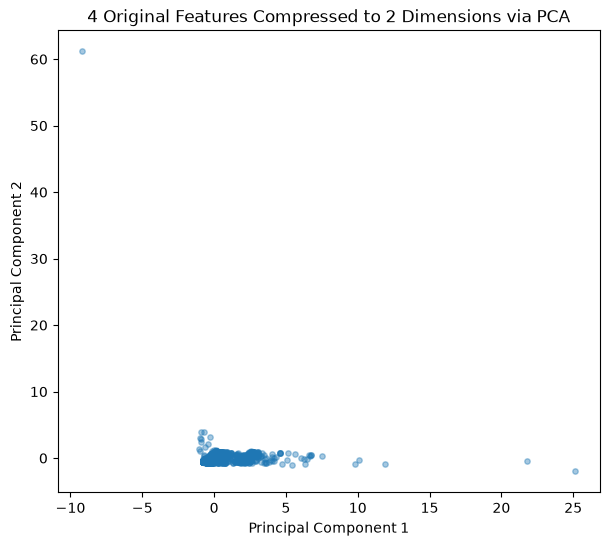

In [5]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca_input = StandardScaler().fit_transform(df[feature_cols].sample(n=5000, random_state=42))
pca = PCA(n_components=2)
pca_result = pca.fit_transform(pca_input)

print("Original number of features:", pca_input.shape[1])
print("Reduced number of components:", pca_result.shape[1])
print("Variance captured by each of the 2 components:", np.round(pca.explained_variance_ratio_, 3))
print("Total variance retained:", round(pca.explained_variance_ratio_.sum(), 3))

plt.figure(figsize=(7, 6))
plt.scatter(pca_result[:, 0], pca_result[:, 1], alpha=0.4, s=15)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("4 Original Features Compressed to 2 Dimensions via PCA")
plt.show()

## Applications

Unsupervised Learning shows up anywhere structure needs to be discovered
without predefined labels:

* **Customer segmentation** — grouping customers by behavior for
  targeted marketing (demonstrated above).
* **Anomaly / fraud detection** — flagging transactions, logins, or
  sensor readings that don't resemble any known normal pattern.
* **Recommendation systems** — grouping similar products or similar
  users to power "customers who bought this also bought..." suggestions.
* **Market basket analysis** — discovering which products tend to be
  purchased together (directly applicable to this retail dataset's
  `Description` and `InvoiceNo` columns).
* **Document / topic clustering** — grouping similar text documents or
  discovering latent topics without manually tagging every document.
* **Image compression and visualization** — dimensionality reduction
  techniques like PCA are used to compress images or visualize
  high-dimensional data (e.g. hundreds of features) in 2D or 3D.
* **Data preprocessing** — using dimensionality reduction to remove noise
  and redundancy before feeding data into a supervised model, or using
  clustering to engineer a new categorical feature.